### SETUP, LIBRARY, & SEED

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms

# Mengunci Seed agar Reproducible
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cuda


### LOAD DATA & EDA (Poin 15%)

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

X = train_df.drop('label', axis=1).values
y = train_df['label'].values

# Split data 80:20 secara konsisten
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### VISUALISASI EDA (Minimal 2 Grafik)

/tmp/ipykernel_4994/1829276654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


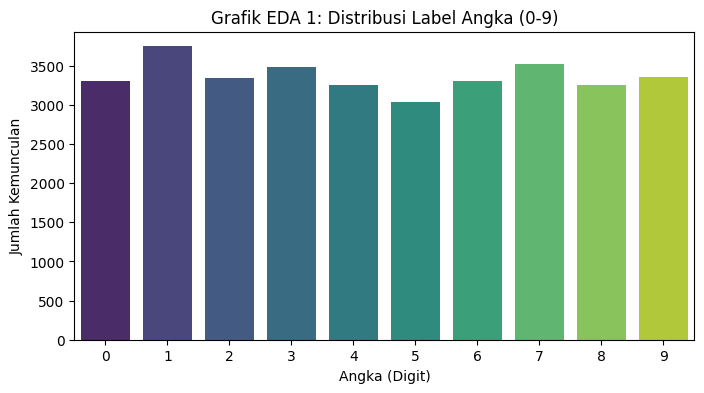

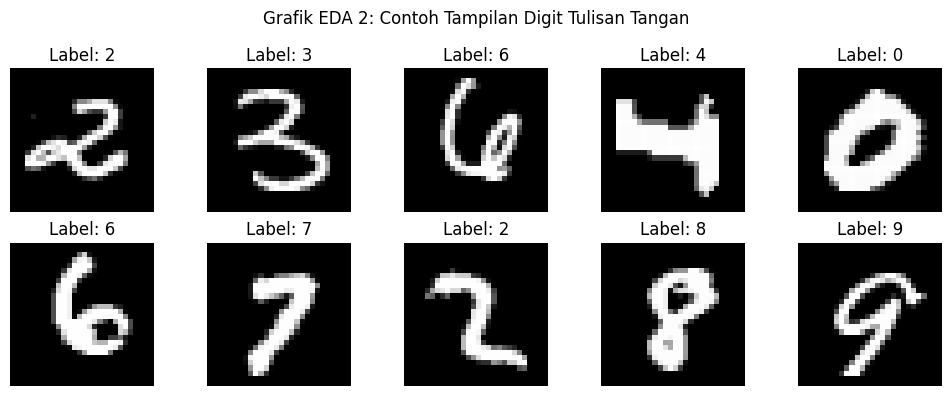

In [3]:
  # Grafik 1: Distribusi Kelas Target pada Training Set
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Grafik EDA 1: Distribusi Label Angka (0-9)')
plt.xlabel('Angka (Digit)')
plt.ylabel('Jumlah Kemunculan')
plt.show()

# Grafik 2: Menampilkan 10 contoh digit gambar
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_raw[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Grafik EDA 2: Contoh Tampilan Digit Tulisan Tangan")
plt.tight_layout()
plt.show()

### CONVENTIONAL ML BASELINE (Poin 15%)

In [4]:
from sklearn.model_selection import RandomizedSearchCV

# --- Kombinasi 1: PCA + Random Forest ---
print("\n[Eksperimen 1] Mengeksekusi PCA + Random Forest (dengan Hyperparameter Tuning)...")
start_time = time.time()

# Normalisasi sederhana 0-1
X_train_norm = X_train_raw / 255.0
X_val_norm = X_val_raw / 255.0

pca = PCA(n_components=0.90, random_state=42) # Mempertahankan 90% varians
X_train_pca = pca.fit_transform(X_train_norm)
X_val_pca = pca.transform(X_val_norm)
print(f"PCA: {pca.n_components_} komponen dari 784 fitur asli (mempertahankan 90% varians)")

# Tuning wajar menggunakan RandomizedSearchCV agar komputasi tetap cepat
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
rf_tuned = RandomizedSearchCV(rf_base, param_distributions=rf_param_grid, n_iter=2, cv=2, random_state=42)
rf_tuned.fit(X_train_pca, y_train)

# Menggunakan model terbaik hasil tuning
rf_conv = rf_tuned.best_estimator_
rf_train_time = time.time() - start_time
print(f"Parameter RF terbaik (hasil tuning): {rf_tuned.best_params_}")

start_inf = time.time()
rf_preds = rf_conv.predict(X_val_pca)
rf_inf_time = time.time() - start_inf

# Cek Overfitting RF
rf_train_preds = rf_conv.predict(X_train_pca)
print(f"PCA+RF Training Accuracy   : {accuracy_score(y_train, rf_train_preds):.4f}")
print(f"PCA+RF Validation Accuracy : {accuracy_score(y_val, rf_preds):.4f}")
print(f"Waktu Training: {rf_train_time:.2f}s | Waktu Inferensi: {rf_inf_time:.2f}s")


# --- Kombinasi 2: HOG + SVM ---
print("\n[Eksperimen 2] Mengeksekusi HOG + SVM (dengan Hyperparameter Tuning)...")

def extract_hog_features(data):
    features = []
    for img in data:
        img_reshaped = img.reshape(28, 28)
        # Ekstraksi HOG sesuai materi
        fd = hog(img_reshaped, orientations=9, pixels_per_cell=(7, 7),
                 cells_per_block=(2, 2), visualize=False)
        features.append(fd)
    return np.array(features)

start_time = time.time()
X_train_hog = extract_hog_features(X_train_raw)
X_val_hog = extract_hog_features(X_val_raw)

# Tuning wajar untuk SVM menggunakan C dan gamma
svm_base = SVC(kernel='rbf', random_state=42)
svm_param_grid = {'C': [1, 10], 'gamma': ['scale', 'auto']}
svm_tuned = RandomizedSearchCV(svm_base, param_distributions=svm_param_grid, n_iter=2, cv=2, random_state=42)
svm_tuned.fit(X_train_hog, y_train)

# Menggunakan model terbaik hasil tuning
svm_conv = svm_tuned.best_estimator_
svm_train_time = time.time() - start_time
print(f"Parameter SVM terbaik (hasil tuning): {svm_tuned.best_params_}")

start_inf = time.time()
svm_preds = svm_conv.predict(X_val_hog)
svm_inf_time = time.time() - start_inf

# Cek Overfitting SVM
SUBSET_SVM = 5000
svm_train_preds_sub = svm_conv.predict(X_train_hog[:SUBSET_SVM])
print(f"HOG+SVM Training Accuracy (subset {SUBSET_SVM:,}): "
      f"{accuracy_score(y_train[:SUBSET_SVM], svm_train_preds_sub):.4f}")
print(f"HOG+SVM Validation Accuracy : {accuracy_score(y_val, svm_preds):.4f}")
print(f"Waktu Training: {svm_train_time:.2f}s | Waktu Inferensi: {svm_inf_time:.2f}s")

# Simpan hasil untuk tabel perbandingan akhir
results_conv = {
    'PCA+RF': {'acc': accuracy_score(y_val, rf_preds), 'train_t': rf_train_time, 'inf_t': rf_inf_time},
    'HOG+SVM': {'acc': accuracy_score(y_val, svm_preds), 'train_t': svm_train_time, 'inf_t': svm_inf_time}
}
print("\nClassification Report — PCA+RF:")
print(classification_report(y_val, rf_preds))
print("\nClassification Report — HOG+SVM:")
print(classification_report(y_val, svm_preds))


[Eksperimen 1] Mengeksekusi PCA + Random Forest (dengan Hyperparameter Tuning)...
PCA: 87 komponen dari 784 fitur asli (mempertahankan 90% varians)
Parameter RF terbaik (hasil tuning): {'n_estimators': 100, 'max_depth': None}
PCA+RF Training Accuracy   : 1.0000
PCA+RF Validation Accuracy : 0.9471
Waktu Training: 109.77s | Waktu Inferensi: 0.14s

[Eksperimen 2] Mengeksekusi HOG + SVM (dengan Hyperparameter Tuning)...
Parameter SVM terbaik (hasil tuning): {'gamma': 'auto', 'C': 10}
HOG+SVM Training Accuracy (subset 5,000): 0.9686
HOG+SVM Validation Accuracy : 0.9692
Waktu Training: 285.62s | Waktu Inferensi: 25.30s

Classification Report — PCA+RF:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       827
           1       0.98      0.98      0.98       937
           2       0.95      0.94      0.94       835
           3       0.92      0.94      0.93       870
           4       0.94      0.95      0.95       814
           5       0

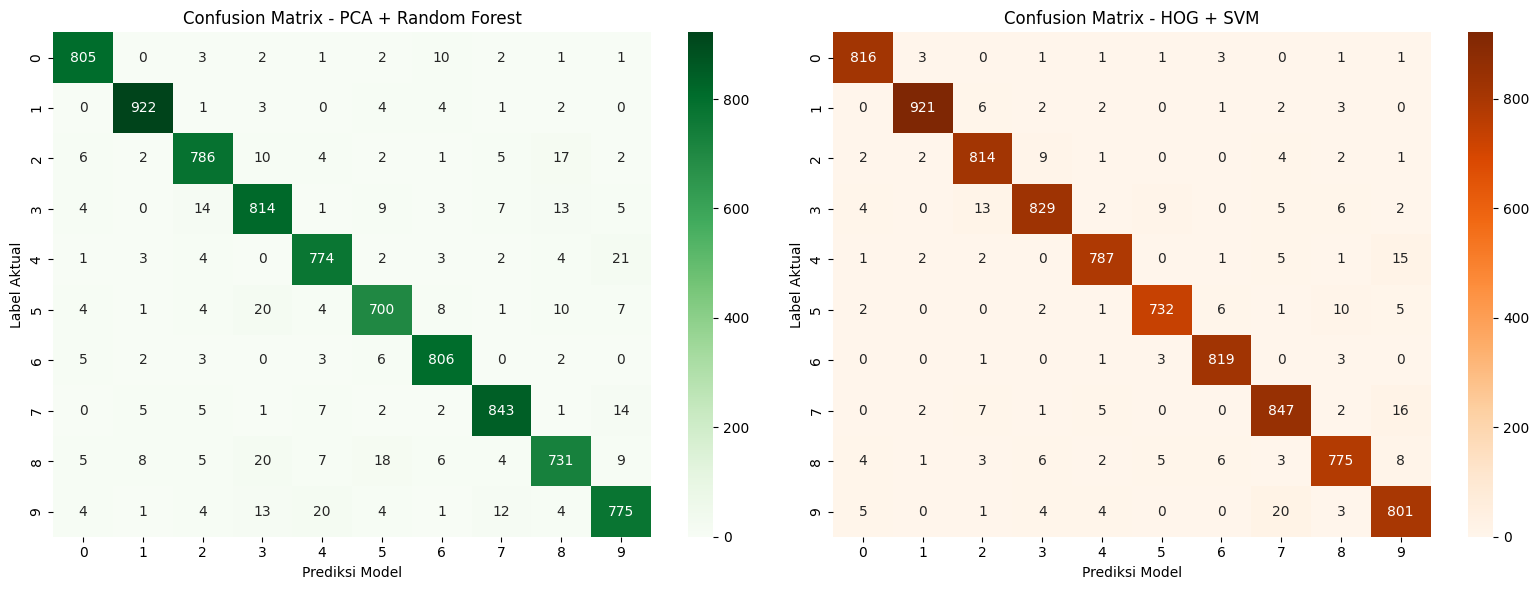

In [5]:
# Confusion Matrix — PCA + Random Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_val, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Confusion Matrix - PCA + Random Forest')
axes[0].set_ylabel('Label Aktual')
axes[0].set_xlabel('Prediksi Model')

cm_svm = confusion_matrix(y_val, svm_preds)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix - HOG + SVM')
axes[1].set_ylabel('Label Aktual')
axes[1].set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

PCA+RF gagal: 444 gambar


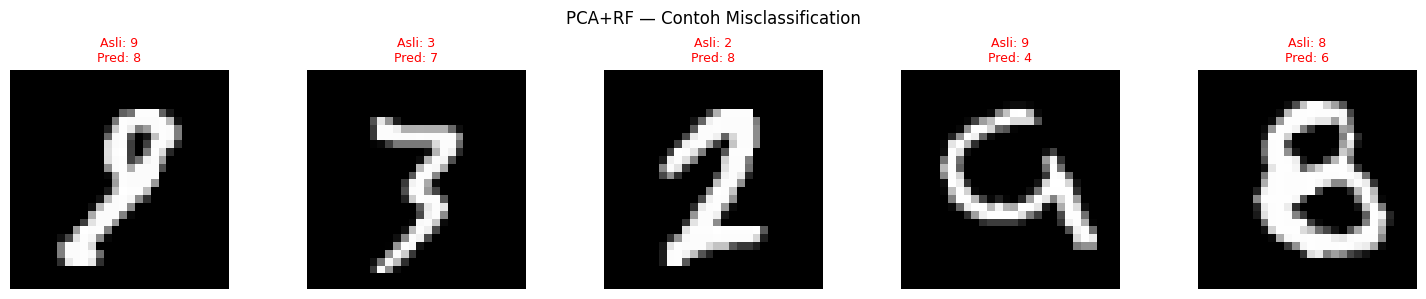

HOG+SVM gagal: 259 gambar


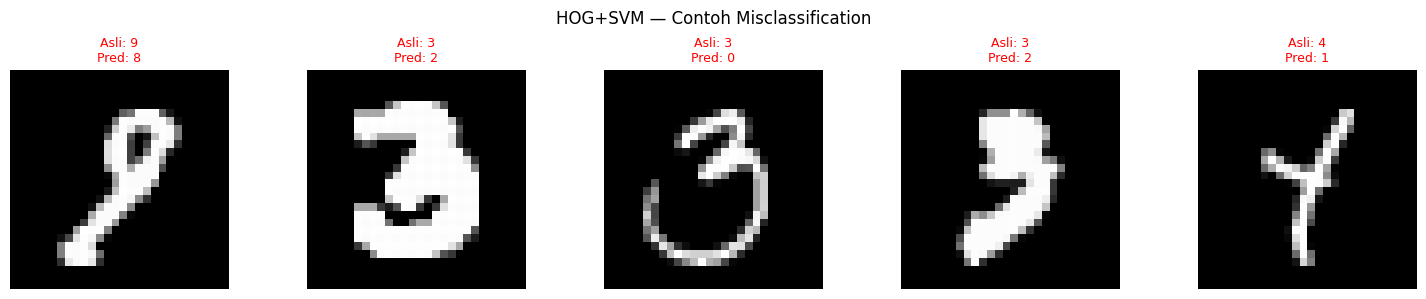

In [6]:
# Contoh gambar gagal: PCA+RF
mis_rf = np.where(y_val != rf_preds)[0]
print(f"PCA+RF gagal: {len(mis_rf)} gambar")
plt.figure(figsize=(15, 3))
for i, idx in enumerate(mis_rf[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_val_raw[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Asli: {y_val[idx]}\nPred: {rf_preds[idx]}", color='red', fontsize=9)
    plt.axis('off')
plt.suptitle("PCA+RF — Contoh Misclassification")
plt.tight_layout()
plt.show()

# Contoh gambar gagal: HOG+SVM
mis_svm = np.where(y_val != svm_preds)[0]
print(f"HOG+SVM gagal: {len(mis_svm)} gambar")
plt.figure(figsize=(15, 3))
for i, idx in enumerate(mis_svm[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_val_raw[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Asli: {y_val[idx]}\nPred: {svm_preds[idx]}", color='red', fontsize=9)
    plt.axis('off')
plt.suptitle("HOG+SVM — Contoh Misclassification")
plt.tight_layout()
plt.show()

### DEEP LEARNING (CNN) + DATA AUGMENTATION


[Eksperimen 3] Mengeksekusi CNN dengan Data Augmentation...
Epoch 1/10 - Train Loss: 0.6006 | Val Loss: 0.1101
Epoch 2/10 - Train Loss: 0.2020 | Val Loss: 0.0697
Epoch 3/10 - Train Loss: 0.1542 | Val Loss: 0.0706
Epoch 4/10 - Train Loss: 0.1313 | Val Loss: 0.0567
Epoch 5/10 - Train Loss: 0.1202 | Val Loss: 0.0536
Epoch 6/10 - Train Loss: 0.1063 | Val Loss: 0.0479
Epoch 7/10 - Train Loss: 0.0959 | Val Loss: 0.0457
Epoch 8/10 - Train Loss: 0.0929 | Val Loss: 0.0423
Epoch 9/10 - Train Loss: 0.0842 | Val Loss: 0.0448
Epoch 10/10 - Train Loss: 0.0804 | Val Loss: 0.0381


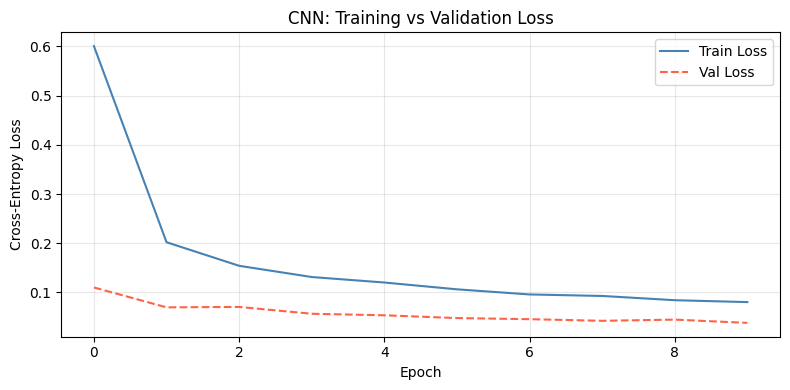


--- Pengecekan Overfitting Deep Learning (CNN) ---
CNN Training Accuracy   : 0.9907
CNN Validation Accuracy : 0.9888
Waktu Training: 176.81s | Waktu Inferensi: 2.5283s

Classification Report — CNN:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       827
           1       0.99      1.00      0.99       937
           2       1.00      0.98      0.99       835
           3       0.99      0.99      0.99       870
           4       1.00      0.99      0.99       814
           5       0.99      0.99      0.99       759
           6       0.99      0.99      0.99       827
           7       0.99      0.99      0.99       880
           8       0.99      0.98      0.99       813
           9       0.97      0.99      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



In [7]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

print("\n[Eksperimen 3] Mengeksekusi CNN dengan Data Augmentation...")

X_train_cnn = X_train_raw.reshape(-1, 28, 28).astype(np.uint8)
X_val_cnn = X_val_raw.reshape(-1, 28, 28).astype(np.uint8)

class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = MNISTDataset(X_train_cnn, y_train, transform=train_transform)
val_dataset   = MNISTDataset(X_val_cnn,   y_val,   transform=val_transform)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1   = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(32 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.25)
        self.fc2     = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

cnn_model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

epochs = 10
cnn_train_losses = []
cnn_val_losses   = []
start_time = time.time()

for epoch in range(epochs):
    # ── 1. TRAINING ──────────────────────────────────────────
    cnn_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    cnn_train_losses.append(epoch_train_loss)

    # ── 2. VALIDATION LOSS ───────────────────────────────────
    cnn_model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            val_running_loss += criterion(outputs, labels).item()
    epoch_val_loss = val_running_loss / len(val_loader)
    cnn_val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

cnn_train_time = time.time() - start_time

# ── PLOT LOSS CURVE ──────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(cnn_train_losses, label='Train Loss', color='steelblue')
plt.plot(cnn_val_losses,   label='Val Loss',   color='tomato', linestyle='--')
plt.title('CNN: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── CEK OVERFITTING (train accuracy) ────────────────────────
train_eval_dataset = MNISTDataset(X_train_cnn, y_train, transform=val_transform)
train_eval_loader  = DataLoader(train_eval_dataset, batch_size=64, shuffle=False)

cnn_model.eval()
cnn_train_preds   = []
cnn_train_targets = []
with torch.no_grad():
    for images, labels in train_eval_loader:
        images = images.to(device)
        _, predicted = torch.max(cnn_model(images), 1)
        cnn_train_preds.extend(predicted.cpu().numpy())
        cnn_train_targets.extend(labels.numpy())

# ── EVALUASI VALIDASI ────────────────────────────────────────
cnn_preds = []
start_inf = time.time()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        _, predicted = torch.max(cnn_model(images), 1)
        cnn_preds.extend(predicted.cpu().numpy())
cnn_inf_time = time.time() - start_inf

print("\n--- Pengecekan Overfitting Deep Learning (CNN) ---")
print(f"CNN Training Accuracy   : {accuracy_score(cnn_train_targets, cnn_train_preds):.4f}")
print(f"CNN Validation Accuracy : {accuracy_score(y_val, cnn_preds):.4f}")
print(f"Waktu Training: {cnn_train_time:.2f}s | Waktu Inferensi: {cnn_inf_time:.4f}s")
print("\nClassification Report — CNN:")
print(classification_report(y_val, cnn_preds))

results_conv['CNN'] = {
    'acc':     accuracy_score(y_val, cnn_preds),
    'train_t': cnn_train_time,
    'inf_t':   cnn_inf_time
}

### ERROR ANALYSIS & PERBANDINGAN PERFORMA


--- Visualisasi Confusion Matrix CNN ---


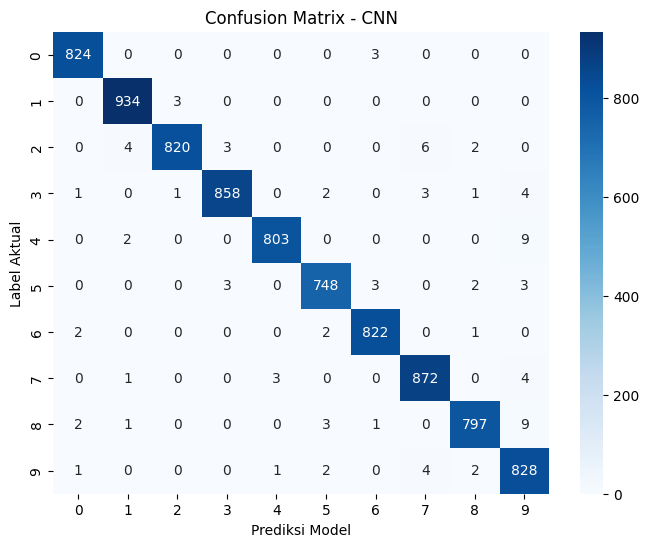


Total gambar yang gagal diklasifikasi oleh CNN: 94 dari 8400
Menampilkan 5 contoh gambar yang gagal diklasifikasi...


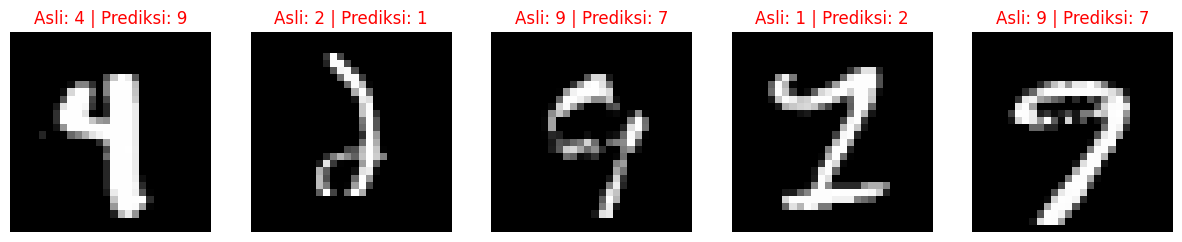

In [8]:
print("\n--- Visualisasi Confusion Matrix CNN ---")
cm_cnn = confusion_matrix(y_val, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN')
plt.ylabel('Label Aktual')
plt.xlabel('Prediksi Model')
plt.show()

# Mencari gambar yang gagal diklasifikasi oleh CNN
misclassified_idx = np.where(y_val != cnn_preds)[0]
print(f"\nTotal gambar yang gagal diklasifikasi oleh CNN: {len(misclassified_idx)} dari {len(y_val)}")
print("Menampilkan 5 contoh gambar yang gagal diklasifikasi...")

plt.figure(figsize=(15, 3))
for i, idx in enumerate(misclassified_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_val_cnn[idx], cmap='gray')
    plt.title(f"Asli: {y_val[idx]} | Prediksi: {cnn_preds[idx]}", color='red')
    plt.axis('off')
plt.show()

### TABEL KESIMPULAN LINTAS MODEL

In [9]:
# --- Menampilkan Tabel Final (Mencakup Parameter & Memori) ---
print("\n--- Tabel Perbandingan Performa Kasus 2 (Sesuai Rubrik) ---")
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

df_mnist = pd.DataFrame({
    'Model': ['PCA + Random Forest', 'HOG + SVM', 'CNN'],
    'Akurasi Validation': [
        f"{results_conv['PCA+RF']['acc']*100:.2f}%",
        f"{results_conv['HOG+SVM']['acc']*100:.2f}%",
        f"{results_conv['CNN']['acc']*100:.2f}%"
    ],
    'Macro F1-Score': [
        f"{f1_score(y_val, rf_preds, average='macro'):.4f}",
        f"{f1_score(y_val, svm_preds, average='macro'):.4f}",
        f"{f1_score(y_val, cnn_preds, average='macro'):.4f}"
    ],
    'Waktu Training': [
        f"{results_conv['PCA+RF']['train_t']:.2f}s",
        f"{results_conv['HOG+SVM']['train_t']:.2f}s",
        f"{results_conv['CNN']['train_t']:.2f}s"
    ],
    'Waktu Inferensi': [
        f"{results_conv['PCA+RF']['inf_t']:.3f}s",
        f"{results_conv['HOG+SVM']['inf_t']:.3f}s",
        f"{results_conv['CNN']['inf_t']:.3f}s"
    ],
    'Estimasi Parameter': [
    f"{pca.n_components_} PC, {rf_conv.n_estimators} trees",
    f"{svm_conv.n_support_.sum():,} support vectors",
    f"{count_parameters(cnn_model):,} params"
    ],
    'Kebutuhan Memori': ['Rendah (CPU)', 'Sedang (CPU RAM)', 'Tinggi (GPU VRAM)']
})
display(df_mnist)


--- Tabel Perbandingan Performa Kasus 2 (Sesuai Rubrik) ---


,Model,Akurasi Validation,Macro F1-Score,Waktu Training,Waktu Inferensi,Estimasi Parameter,Kebutuhan Memori
0,PCA + Random Forest,94.71%,0.9464,109.77s,0.141s,"87 PC, 100 trees",Rendah (CPU)
1,HOG + SVM,96.92%,0.9691,285.62s,25.295s,"8,088 support vectors",Sedang (CPU RAM)
2,CNN,98.88%,0.9887,176.81s,2.528s,"206,922 params",Tinggi (GPU VRAM)


### SUBMISSION KAGGLE KASUS 2

In [10]:
# Ekstrak nilai piksel dari test_df dan reshape
X_test_raw = test_df.values
X_test_cnn = X_test_raw.reshape(-1, 28, 28).astype(np.uint8)

# Custom Dataset untuk Test (Tanpa Label)
class MNISTTestDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img

# Gunakan val_transform (TIDAK BOLEH pakai train_transform agar data test tidak terdistorsi/teracak)
test_dataset = MNISTTestDataset(X_test_cnn, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Memulai Prediksi
cnn_model.eval()
test_preds = []
with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_preds.extend(predicted.cpu().numpy())

# Format submission Kaggle untuk Digit Recognizer: ImageId (1 sampai N) dan Label
submission = pd.DataFrame({
    "ImageId": range(1, len(test_preds) + 1),
    "Label": test_preds
})
submission.to_csv('mnist_cnn_submission.csv', index=False)
print("File 'mnist_cnn_submission.csv' BERHASIL dibuat! Silakan download dan submit ke Kaggle.")

File 'mnist_cnn_submission.csv' BERHASIL dibuat! Silakan download dan submit ke Kaggle.
